In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

## EDA

In [69]:
data = pd.read_csv("marketing_AB.csv", index_col="Unnamed: 0")

data.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [70]:
data = data.drop(columns='user id')

data.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


In [71]:
print(data.shape)
print(data.info())

(588101, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   test group     588101 non-null  object
 1   converted      588101 non-null  bool  
 2   total ads      588101 non-null  int64 
 3   most ads day   588101 non-null  object
 4   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 23.0+ MB
None


In [72]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


In [73]:
print("Test group's types:", data['test group'].unique())

Test group's types: ['ad' 'psa']


In [74]:
data['converted'] = data['converted'].astype(int)

data['converted'].value_counts()

converted
0    573258
1     14843
Name: count, dtype: int64

In [75]:
group_means = data.groupby('test group')['converted'].mean()
groups = group_means.index
conversion_rates = group_means.values

In [76]:

cmap = plt.cm.plasma  

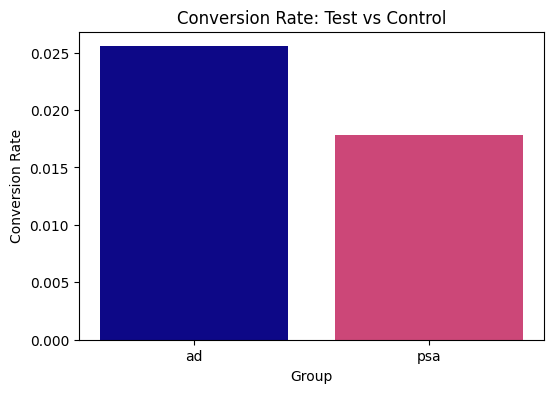

In [77]:
plt.figure(figsize=(6,4))
plt.bar(groups, conversion_rates, color=[cmap(i/len(groups)) for i in range(len(groups))])
plt.title("Conversion Rate: Test vs Control")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

In [78]:
day_means = data.groupby('most ads day')['converted'].mean().reset_index()
days = day_means['most ads day']
conversion_rates_by_day = day_means['converted']

Text(0, 0.5, 'Conversion rate')

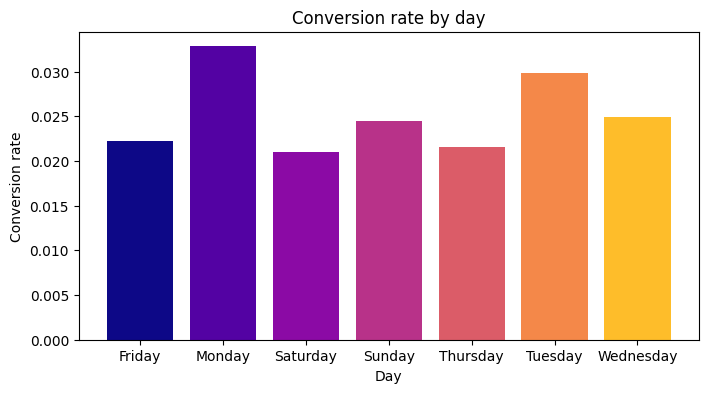

In [79]:
plt.figure(figsize=(8,4))
colors = [cmap(i/len(days)) for i in range(len(days))]
plt.bar(days, conversion_rates_by_day, color=colors)
plt.title("Conversion rate by day")
plt.xlabel("Day")
plt.ylabel("Conversion rate")


In [80]:
hour_means = data.groupby('most ads hour')['converted'].mean()
hours = hour_means.index
convertion_rate_by_hour = hour_means.values

Text(0, 0.5, 'Convertion rate')

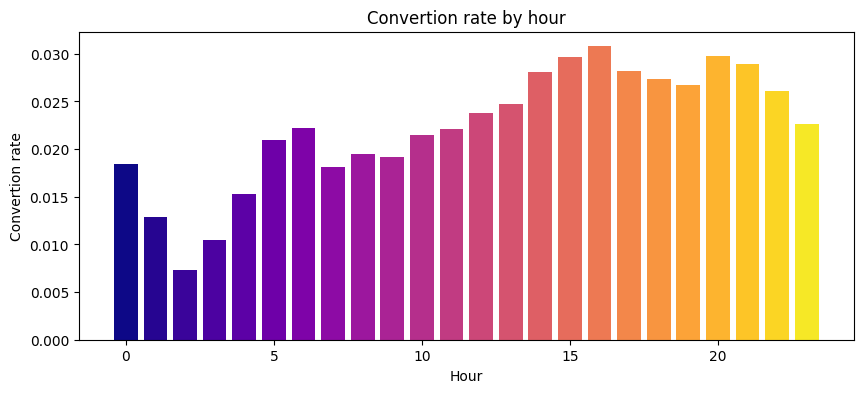

In [81]:
plt.figure(figsize=(10, 4))
plt.bar(hours, convertion_rate_by_hour, color=[cmap(i/len(hours)) for i in range(len(hours))])
plt.title("Convertion rate by hour")
plt.xlabel("Hour")
plt.ylabel("Convertion rate")

## A/B-testing

In [82]:
alpha = 0.05

control_group = data[data['test group'] == 'psa']
test_group = data[data['test group'] == 'ad']

control_convertion = control_group['converted']
test_convertion = test_group['converted']

z_stat, p_value = proportions_ztest(
    count=[sum(control_convertion), sum(test_convertion)],
    nobs=[len(control_convertion), len(test_convertion)]
)

In [86]:
conv_control = sum(control_convertion) / len(control_convertion)
conv_test = sum(test_convertion) / len(test_convertion)

print(f"Конверсия в контрольной группе: {conv_control:.2%}")
print(f"Конверсия в тестовой группе:     {conv_test:.2%}")
print(f"Разница:  {conv_test - conv_control:.2%}")
print(f"Относительная разность: {(conv_test - conv_control) / conv_control *100:.1f}%")

Конверсия в контрольной группе: 1.79%
Конверсия в тестовой группе:     2.55%
Разница:  0.77%
Относительная разность: 43.1%


In [87]:
print("Z-статистика:", z_stat)
print("P-value:", p_value)

Z-статистика: -7.3700781265454145
P-value: 1.7052807161559727e-13


In [90]:
if p_value < alpha:
    print("Результат статистически значим, поэтому отвергаем H0. Тест можно считать успешным (зелёный).")
else:
    print("Результат статистически не значим, поэтому нет оснований отвергнуть H0. Тест нельзя считать успешным.")

Результат статистически значим, поэтому отвергаем H0. Тест можно считать успешным (зелёный).
